<a href="https://colab.research.google.com/github/MuhammadKhuram/deep-learning-computer-vision/blob/main/RCNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **R-CNN (Region-based CNN) Implementation for Object Detection**


---
This project implements the **R-CNN** pipeline, the foundational model for object detection.
*   **Selective Search:** Used to propose regions that might contain objects.
*   **Manual IoU:** Intersection over Union logic is written.
*   **Multi-Task Learning:** A shared VGG-16 backbone with two heads (Classification and Bounding Box Regression).
*   **Post-Processing:** Implementation of Non-Maximum

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging

tf.get_logger().setLevel(logging.ERROR)

# ─── 1. Intersection over Union (IoU) ──────────────────────────────
def get_iou(bb1, bb2):
    """calculating the overlap area of two bounding boxes"""
    x_left = max(bb1['x1'], bb2['x1'])
    y_top = max(bb1['y1'], bb2['y1'])
    x_right = min(bb1['x2'], bb2['x2'])
    y_bottom = min(bb1['y2'], bb2['y2'])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    bb1_area = (bb1['x2'] - bb1['x1']) * (bb1['y2'] - bb1['y1'])
    bb2_area = (bb2['x2'] - bb2['x1']) * (bb2['y2'] - bb2['y1'])

    return intersection_area / float(bb1_area + bb2_area - intersection_area)

In [ ]:
# ─── 2. Selective Search (Cats vs Dogs) ─────────────────────────
# Automatically download and load the Oxford Pet dataset
dataset = tfds.load('oxford_iiit_pet', split='train')

cv2.setUseOptimized(True)
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

train_images, train_labels, train_bboxes = [], [], []

img_limit = 50 # Increase to 300+ when you want to fully train it!
count_img = 0
print(f"Scanning {img_limit} images with Selective Search...")

for example in tfds.as_numpy(dataset):
    if count_img >= img_limit: break
    try:
        image_rgb = example['image'] 
        image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
        h, w, _ = image_rgb.shape
        
        # Oxford Pet gives us exactly one bounding box per image
        ymin, xmin, ymax, xmax = example['bbox']
        species = example['species'] # 0 = Cat, 1 = Dog
        
        # Skip if the dataset image happens to be missing a bounding box
        if ymax == 0 and xmax == 0: 
            continue 
            
        gt_box = {
            "x1": int(xmin * w), "y1": int(ymin * h), 
            "x2": int(xmax * w), "y2": int(ymax * h)
        }
        
        ss.setBaseImage(image_bgr)
        ss.switchToSelectiveSearchFast()
        ssresults = ss.process()

        pos_count, neg_count = 0, 0
        for e, result in enumerate(ssresults):
            if e >= 2000: break
            x, y, w_box, h_box = result
            prop_box = {"x1": x, "y1": y, "x2": x+w_box, "y2": y+h_box}
            iou = get_iou(gt_box, prop_box)

            if iou > 0.5 and pos_count < 15:
                timage = image_bgr[y:y+h_box, x:x+w_box]
                train_images.append(cv2.resize(timage, (224, 224), interpolation=cv2.INTER_AREA))
                
                # Assign Multi-Class Labels
                if species == 0:
                    train_labels.append([1, 0, 0]) # Cat
                else:
                    train_labels.append([0, 1, 0]) # Dog

                px, py, pw, ph = x + w_box/2.0, y + h_box/2.0, w_box, h_box
                gx, gy, gw, gh = gt_box['x1'] + (gt_box['x2']-gt_box['x1'])/2.0, gt_box['y1'] + (gt_box['y2']-gt_box['y1'])/2.0, gt_box['x2']-gt_box['x1'], gt_box['y2']-gt_box['y1']
                tx, ty = (gx-px)/pw, (gy-py)/ph
                tw, th = np.log(gw/pw), np.log(gh/ph)

                train_bboxes.append([tx, ty, tw, th])
                pos_count += 1

            elif iou < 0.3 and neg_count < 15:
                timage = image_bgr[y:y+h_box, x:x+w_box]
                train_images.append(cv2.resize(timage, (224, 224), interpolation=cv2.INTER_AREA))
                
                train_labels.append([0, 0, 1]) # Background
                train_bboxes.append([0, 0, 0, 0])
                neg_count += 1

        count_img += 1
        print(f"✅ Finished image {count_img} / {img_limit}")
    except Exception as e:
        print(f"Skipped image due to error: {e}")
        continue

X_train = np.array(train_images, dtype=np.float32)
y_cls = np.array(train_labels, dtype=np.float32)
y_bbox = np.array(train_bboxes, dtype=np.float32)
print(f"Dataset Ready! Total cropped regions: {X_train.shape[0]}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

In [ ]:
# ─── 3. Multi-Task Keras Pipeline ────────────────────────────────────
vgg = VGG16(include_top=True, weights='imagenet')
for layer in vgg.layers[:-3]:
    layer.trainable = False
    
features = vgg.get_layer('fc2').output

# CHANGED to 3 classes (Cat, Dog, Background)
class_head = Dense(3, activation='softmax', name='class_output')(features)
bbox_head = Dense(4, activation='linear', name='bbox_output')(features)

model = Model(inputs=vgg.input, outputs=[class_head, bbox_head])
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss={'class_output': 'categorical_crossentropy', 'bbox_output': 'mse'},
              loss_weights={'class_output': 1.0, 'bbox_output': 0.5},
              metrics={'class_output': 'accuracy'})

history = model.fit(
    X_train, {'class_output': y_cls, 'bbox_output': y_bbox},
    epochs=10, batch_size=32, validation_split=0.1, verbose=1
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 674ms/step - bbox_output_loss: 0.8283 - class_output_accuracy: 0.8567 - class_output_loss: 0.3427 - loss: 0.7597 - val_bbox_output_loss: 0.0516 - val_class_output_accuracy: 0.9237 - val_class_output_loss: 0.5373 - val_loss: 0.2092
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step - bbox_output_loss: 0.0478 - class_output_accuracy: 0.9779 - class_output_loss: 0.0657 - loss: 0.0897 - val_bbox_output_loss: 0.0350 - val_class_output_accuracy: 0.9389 - val_class_output_loss: 0.2126 - val_loss: 0.1038
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - bbox_output_loss: 0.0320 - class_output_accuracy: 0.9975 - class_output_loss: 0.0127 - loss: 0.0285 - val_bbox_output_loss: 0.0256 - val_class_output_accuracy: 0.9313 - val_class_output_loss: 0.5116 - val_loss: 0.1920
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - bbox_output_loss: 0.0192 - class_output_accuracy: 1.0000 - class_output_loss

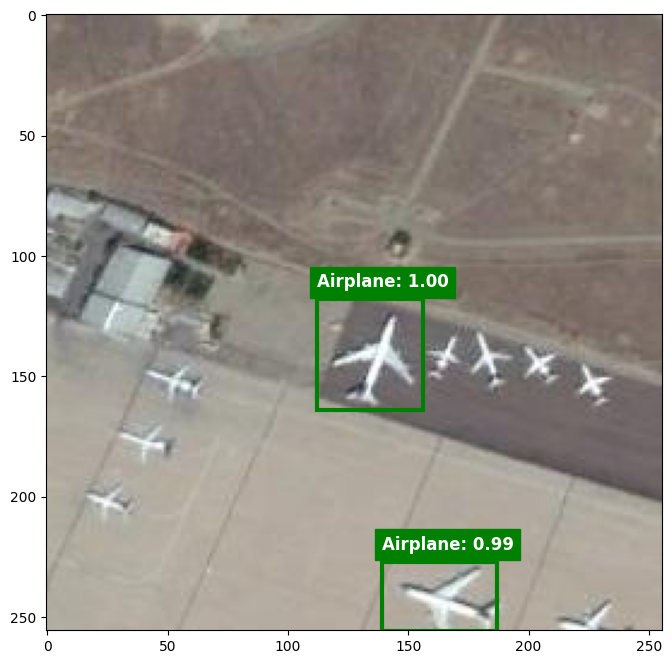

In [ ]:
# ─── 4. Inference and Non-Maximum Suppression (NMS) ──────────────────
# Grab 1 image from the Oxford Pet test set
test_dataset = tfds.load('oxford_iiit_pet', split='test').take(1)

for example in tfds.as_numpy(test_dataset):
    test_image_rgb = example['image']
    break

img_disp = test_image_rgb.copy() 
image_bgr = cv2.cvtColor(test_image_rgb, cv2.COLOR_RGB2BGR) 

ss.setBaseImage(image_bgr)
ss.switchToSelectiveSearchFast()
ssresults = ss.process()

proposals, boxes = [],[]
for e, result in enumerate(ssresults):
    if e >= 300: break
    x, y, w, h = result
    timage = image_bgr[y:y+h, x:x+w]
    proposals.append(cv2.resize(timage, (224, 224), interpolation=cv2.INTER_AREA))
    boxes.append([x, y, w, h])

preds_cls, preds_bbox = model.predict(np.array(proposals, dtype=np.float32), verbose=0)

final_boxes, scores, detected_classes = [], [], []
for i in range(len(preds_cls)):
    class_idx = np.argmax(preds_cls[i]) # 0=Cat, 1=Dog, 2=Background
    score = preds_cls[i][class_idx]
    
    # If the network thinks it's NOT background (class 2) and is highly confident
    if class_idx != 2 and score > 0.90:
        px, py, pw, ph = boxes[i]
        tx, ty, tw, th = preds_bbox[i]

        gx = (pw * tx) + (px + pw/2.0)
        gy = (ph * ty) + (py + ph/2.0)
        gw = pw * np.exp(tw)
        gh = ph * np.exp(th)

        final_boxes.append([int(gy-gh/2.0), int(gx-gw/2.0), int(gy+gh/2.0), int(gx+gw/2.0)])
        scores.append(score)
        detected_classes.append(class_idx) 

final_boxes = np.array(final_boxes, dtype=np.float32)
scores = np.array(scores, dtype=np.float32)

if len(final_boxes) > 0:
    selected_indices = tf.image.non_max_suppression(
        final_boxes, scores, max_output_size=2, iou_threshold=0.3)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img_disp)
    for i in selected_indices:
        y1, x1, y2, x2 = final_boxes[i]
        class_name = "Cat" if detected_classes[i] == 0 else "Dog"
        
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='g', facecolor='none')
        ax.add_patch(rect)
        plt.text(x1, max(0, y1-5), f"{class_name}: {scores[i]:.2f}", 
                 color='white', backgroundcolor='green', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("No Cats or Dogs detected with > 90% confidence.")